# Predicción del abandono de clientes en telecomunicaciones

## Descripción del problema y análisis exploratorio de datos Dataset: Telco Customer Churn

## 1. Contexto del problema
En la industria de telecomunicaciones, la pérdida de clientes (customer churn) representa un problema crítico debido a que adquirir nuevos clientes suele ser significativamente más costoso que mantener los existentes. Identificar de manera temprana a los clientes con alta probabilidad de abandono permite diseñar estrategias de retención más efectivas.
Este problema puede abordarse mediante técnicas de aprendizaje automático, modelando la probabilidad de abandono a partir de variables demográficas, servicios contratados y comportamientos de facturación de servicios. Todo esto posibilita la implementación de estrategias preventivas como ofertas personalizadas, mejoras en el servicio o planes de fidelización dirigidos específicamente a clientes en riesgo.

El objetivo de este proyecto es desarrollar un modelo de clasificación supervisada capaz de estimar la probabilidad de abandono a partir de variables estructuradas del dataset **Telco Customer Churn**.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
url = "https://raw.githubusercontent.com/DahianaRH/customer-churn-prediction-ml/main/data/telco_customer_churn.csv"
df = pd.read_csv(url)

### Exploración General

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


La muestra del dataset evidencia que se cuenta con variables demográficas, de servicios contratados y de facturación, las cuales serán utilizadas para predecir la variable objetivo Churn.

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset contiene 7043 registros y 21 variables, predominando las variables categóricas. No se observan valores nulos inicialmente, aunque TotalCharges requiere conversión a tipo numérico para su correcto análisis.

## 2. Descripción del dataset
El dataset contiene información de aproximadamente 7000 clientes y 21 variables, incluyendo datos demográficos, servicios contratados y variables de facturación.

La variable objetivo es **Churn**, que nos indica si el cliente abandonó el servicio (Yes/No).

### Tipos de variables

In [9]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


La mayoría de las variables son categóricas y deberán ser codificadas. Además, TotalCharges requiere conversión a tipo numérico para su correcto análisis.

### Análisis de valores faltantes

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Se observa que la mayoría de las variables no presentan valores faltantes. Sin embargo, la variable TotalCharges contiene 11 valores nulos, los cuales representan una proporción muy pequeña del dataset. Por esta razón se decide eliminar estas filas para evitar inconsistencias en el análisis.

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).copy()

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Luego del tratamiento, se verifica que el dataset no presenta valores faltantes en ninguna variable, por lo que se encuentra listo para las etapas posteriores de análisis y modelado.

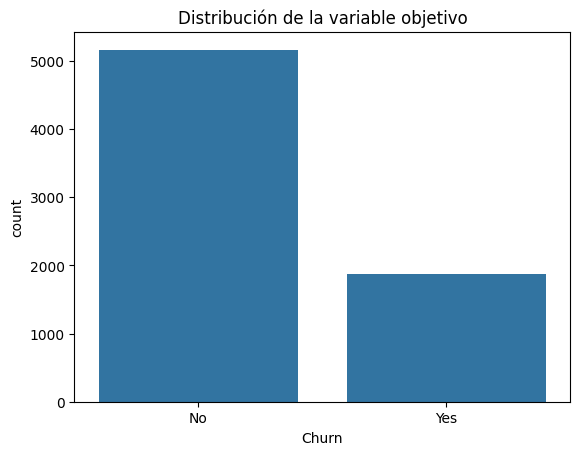

In [14]:
sns.countplot(x='Churn', data=df)
plt.title("Distribución de la variable objetivo")
plt.show()

Se observa un desbalance de clases, lo cual debemos tener en consideración en etapas posteriores mediante técnicas de balanceo o métricas adecuadas, pues métricas cómo accuracy no son suficientes. Se deberán considerar métricas como F1-score, ROC-AUC o PR-AUC.

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Las variables numéricas muestran una alta variabilidad. tenure indica que existen tanto clientes nuevos como antiguos.
MonthlyCharges presenta distintos niveles de cobro según el tipo de servicio.
TotalCharges varía ampliamente, lo cual es consistente con su relación con el tiempo de permanencia y el costo mensual.
Además, se observan algunos valores faltantes en esta última variable.

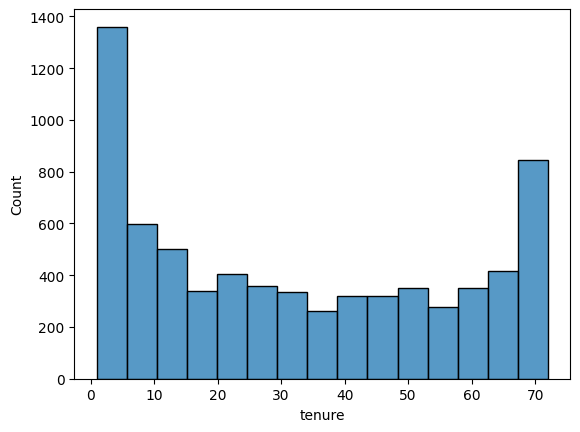

In [16]:
sns.histplot(df['tenure'])
plt.show()

La variable tenure, que representa el tiempo de permanencia del cliente, presenta una distribución no uniforme. Se observa una alta concentración de clientes en los primeros meses, así como un segundo grupo importante de clientes con larga permanencia (mayor a 60 meses). Esto sugiere la existencia de dos perfiles:
1.   Clientes nuevos con mayor probabilidad de abandono
2.   Clientes consolidados con menor riesgo.

Esto nos indica que esta variable tiene un alto poder predictivo para el problema de churn.

In [17]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

La variable objetivo Churn fue codificada en formato binario, asignando el valor 1 a los clientes que abandonan el servicio (Yes) y 0 a los que permanecen (No), con el fin de ser utilizada en modelos de clasificación supervisada.

## 3. Paradigma de aprendizaje

El problema se aborda como una tarea de **clasificación supervisada**, ya que se dispone de etiquetas (Churn) y el objetivo es predecir si un cliente abandonará el servicio.

Sea **X** el conjunto de variables predictoras y **y = Churn** la variable objetivo.
El problema se formula como una clasificación binaria supervisada donde se busca aprender una función **f(X) → y.**

Este enfoque es adecuado debido a la naturaleza del problema y la disponibilidad de datos históricos etiquetados.

In [18]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

## 4. Entrenamiento y Evaluación de los Modelos

### 4.1. Configuración Experimental

### Metodología de validación:
Se realizó el entranamiento y evaluación de diferentes modelos de clasificación supervisada con el objetivo de predecir el abandono de clientes (Churn) en una empresa de telecomunicaciones.

El dataset fue dividido en conjuntos de entrenamiento y prueba utilizando la partición estratificada de:

*   80% para entrenamiento
*   20% para pruebas

La estratificación se realizó utilizando la variable objetivo (abandono) Churn, garantizando que la proporción de clases se mantuviera en ambos conjuntos.

Debido a que el problema presenta desbalance de clases, se utilizaron métricas de evaluación adicionales al accuracy y, en los modelos que son compatibles, se empleó el parámetro class_weith='balanced' para compensar el efecto de la clase minoritaria.

Las variables categóricas fueron transformadas mediante codificación One-Hot Encoding, mientras que las variables numéricas fueron estandarizadas utilizando StandardScaler.

Para evaluar de forma adecuada el desemepeño de los modelos, se utilizó validación cruzada estratificada (StratifiedKFold) con cinco particiones durante el proceso de búsqueda de hiperparámetros mediante GridSearchCV.



In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

### Preparación de variables

In [20]:
# Variables numéricas y categóricas
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# Preprocesamiento
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Validación cruzada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Modelos e hiperparámetros evaluados

Se evaluaron cinco modelos de clasificación supervisada pertenecientes a diferentes paradigmas de aprendizaje automático:



*   Regresión logística
*   K-Nearest Neighbors (KNN)
*   Random Forest
*   Máquina de vectores de soporte (SVM)
*   Red neuronal artificial (MLP)

La Tabla 1 resume los hiperparámetros analizados para cada modelo.

### Tabla 1. Hiperparámetros evaluados

| Modelo | Hiperparámetros |
|---|---|
| Logistic Regression | C = [0.01, 0.1, 1, 10] |
| KNN | n_neighbors = [3, 5, 7, 9] |
| Random Forest | n_estimators = [100, 200], max_depth = [5, 10, None] |
| SVM | C = [0.1, 1, 10], kernel = ['linear', 'rbf'] |
| MLP | hidden_layer_sizes = [(50,), (100,), (50,50)] |

In [21]:
models = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [3,5,7,9]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        {
            'model__n_estimators': [100,200],
            'model__max_depth': [5,10,None]
        }
    ),

    "SVM": (
        SVC(
            probability=True,
            class_weight='balanced'
        ),
        {
            'model__C': [0.1,1,10],
            'model__kernel': ['linear','rbf']
        }
    ),

    "MLP": (
        MLPClassifier(max_iter=1000),
        {
            'model__hidden_layer_sizes': [
                (50,),
                (100,),
                (50,50)
            ]
        }
    )
}

### Métricas de desempeño

Debido al desbalance presente en la variable objetivo, el accuracy no es suficiente para evaluar correctamente el desempeño del sistema.

Por esta razón se utilizaron las siguientes métricas:


*   Accuracy
*   Precision
*   Recall
*   F1-score
*   ROC-AUC

El recall resulta muy importante en este problema porque va a permitir medir la capacidad del modelo para identificar correctamente clientes con riesgo de abandono.

El F1-score va a permitir balancear precision y recall, mientras que la métrica ROC-AUC evalúa la capacidad global de separación entre clases.



### 4.2. Resultados del entrenamiento de modelos

In [22]:
results = []

best_models = {}

for name, (model, params) in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        params,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    })

In [23]:
results_df = pd.DataFrame(results)

results_df

,Model,Best Params,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,{'model__C': 1},0.725657,0.490132,0.796791,0.606925,0.835093
1,KNN,{'model__n_neighbors': 9},0.771144,0.571038,0.558824,0.564865,0.803891
2,Random Forest,"{'model__max_depth': 5, 'model__n_estimators':...",0.724236,0.488333,0.783422,0.601643,0.833105
3,SVM,"{'model__C': 1, 'model__kernel': 'rbf'}",0.729211,0.494017,0.772727,0.602711,0.805617
4,MLP,"{'model__hidden_layer_sizes': (50,)}",0.779673,0.593023,0.545455,0.568245,0.810734


### Tabla 2. Resultados de desempeño de los modelos

La Tabla 2 presenta el desempeño obtenido por los diferentes modelos de clasificación evaluados sobre el conjunto de prueba.

Los mejores resultados en términos de Accuracy fueron obtenidos por el modelo MLP (0.7797) y KNN (0.7711), indicando una mayor proporción global de predicciones correctas. Sin embargo, debido al desbalance de clases presente en la variable objetivo, métricas como Recall, F1-score y ROC-AUC resultan más relevantes para este problema.

El modelo de Logistic Regression obtuvo el mayor Recall (0.7968), seguido por Random Forest (0.7834) y SVM (0.7727), lo que indica una mejor capacidad para identificar correctamente clientes con riesgo de abandono. Esto es especialmente importante en problemas de churn prediction, donde detectar clientes que podrían abandonar el servicio tiene alta relevancia estratégica.

En cuanto al F1-score, los modelos Logistic Regression, SVM y Random Forest presentaron resultados similares cercanos a 0.60, mostrando un balance adecuado entre precision y recall.

Respecto al ROC-AUC, los mejores resultados fueron obtenidos por Logistic Regression (0.8351) y Random Forest (0.8331), evidenciando una buena capacidad discriminativa entre clientes que abandonan y clientes que permanecen.

En general, los resultados muestran que Logistic Regression y Random Forest presentan el desempeño más equilibrado considerando las métricas más relevantes del problema, por lo que serán utilizados en las siguientes etapas de reducción de dimensión.

### Curvas ROC

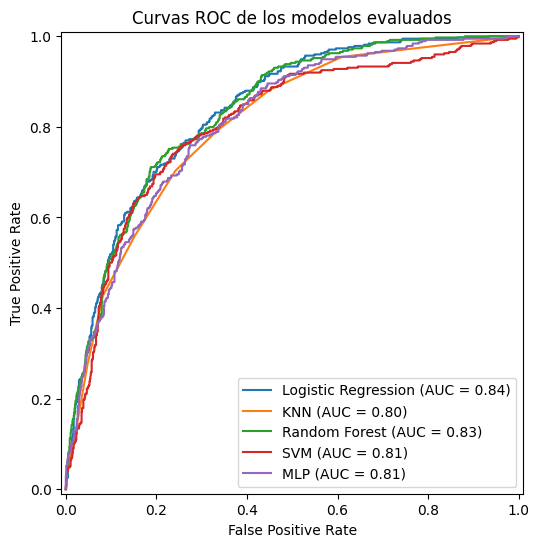

In [24]:
plt.figure(figsize=(8,6))

for name, model in best_models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=plt.gca()
    )

plt.title("Curvas ROC de los modelos evaluados")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Figura 1. Curvas ROC de los modelos evaluados

La Figura 1 presenta las curvas ROC obtenidas para los diferentes modelos evaluados, permitiendo comparar su capacidad para distinguir entre clientes que abandonan el servicio y clientes que permanecen.

Todos los modelos presentan un desempeño adecuado, ya que sus curvas se encuentran por encima de la línea de clasificación aleatoria. Los mejores resultados fueron obtenidos por Logistic Regression (AUC = 0.84) y Random Forest (AUC = 0.83), evidenciando una mejor capacidad discriminativa respecto a los demás modelos.

Por otro lado, KNN, SVM y MLP obtuvieron valores de AUC cercanos a 0.80, mostrando también un desempeño competitivo, aunque ligeramente inferior. En general, los resultados respaldan la selección de Logistic Regression y Random Forest como los modelos más sólidos para las siguientes etapas del proyecto.

### Matriz de confusión del mejor modelo

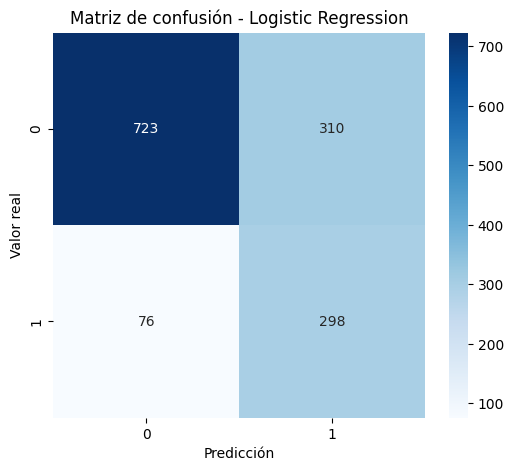

In [25]:
best_model_name = results_df.sort_values(
    by='F1-score',
    ascending=False
).iloc[0]['Model']

best_model = best_models[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

### Figura 2. Matriz de confusión del mejor modelo

La Figura 2 presenta la matriz de confusión obtenida para el modelo Logistic Regression, el cual mostró el desempeño más equilibrado durante la evaluación.

Se observa que el modelo logró clasificar correctamente 723 clientes que no abandonaron el servicio y 298 clientes que sí presentaron churn. Además, el número de falsos negativos fue relativamente bajo (76 casos), lo cual es importante en este problema, ya que permite identificar una mayor cantidad de clientes en riesgo de abandono.

Sin embargo, también se observa una cantidad considerable de falsos positivos (310 casos), indicando que algunos clientes fueron clasificados como churn cuando realmente permanecían en el servicio.

## 5. Reducción de dimensión

### 5.1. Análisis individual de variables.

Con el objetivo de identificar variables redundantes o poco informativas, se realizó un análisis de correlación e importancia de carácterísticas.

### Correlación entre variables numéricas

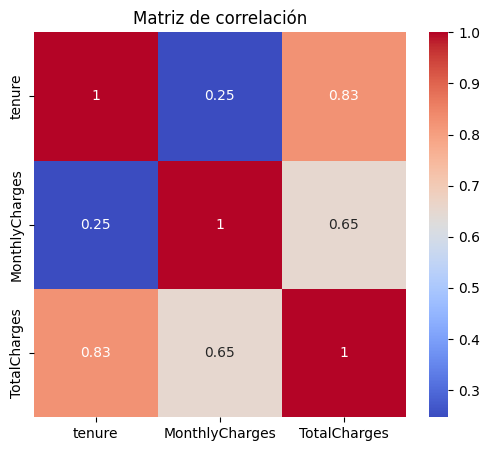

In [26]:
corr = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación")

plt.show()

### Figura 3. Matriz de correlación entre variables numéricas
La Figura 3 muestra la correlación existente entre las variables numéricas del dataset. Se observa una correlación alta entre tenure y TotalCharges (0.83), lo cual es coherente, ya que los clientes con mayor tiempo de permanencia suelen acumular un mayor costo total del servicio.

Asimismo, MonthlyCharges presenta una correlación moderada con TotalCharges (0.65), indicando que el valor mensual también influye en el costo acumulado del cliente.

Por otro lado, la correlación entre tenure y MonthlyCharges es baja (0.25), lo que sugiere que el tiempo de permanencia no depende directamente del costo mensual del servicio.

### Importancia de variables

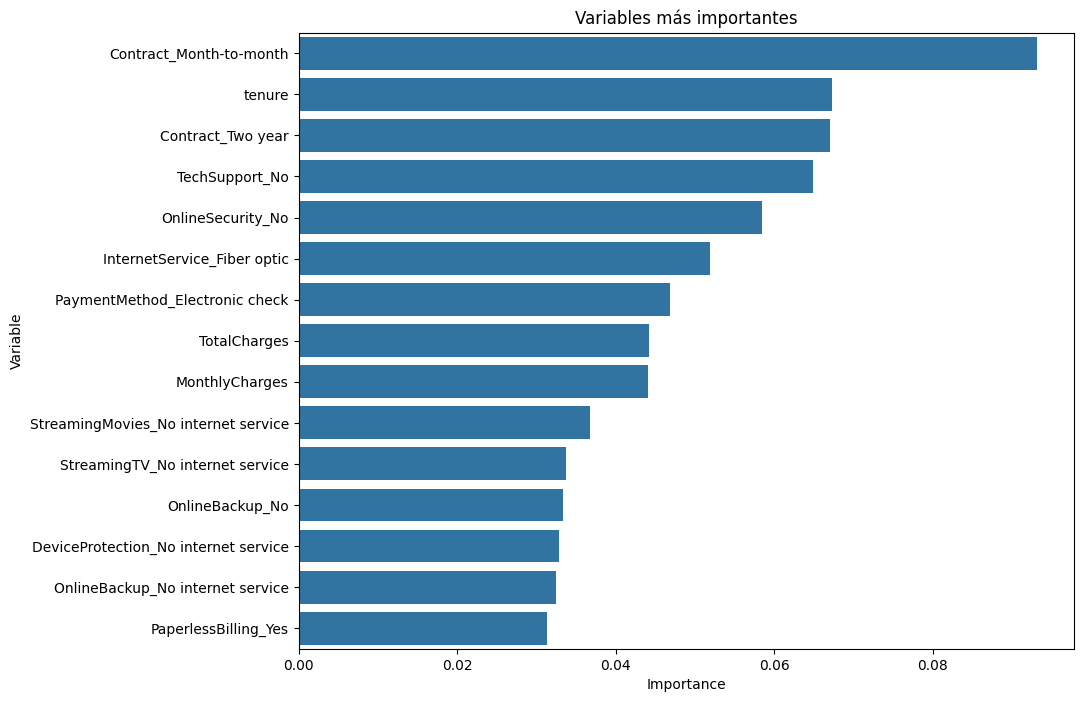

In [27]:
from sklearn.feature_selection import mutual_info_classif

X_encoded = pd.get_dummies(X)

mi_scores = mutual_info_classif(
    X_encoded,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Variable': X_encoded.columns,
    'Importance': mi_scores
})

mi_df = mi_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_df.head(15),
    x='Importance',
    y='Variable'
)

plt.title("Variables más importantes")

plt.show()

### Figura 4. Importancia de variables usando Mutual Information
La Figura 4 presenta las variables con mayor capacidad discriminativa respecto a la variable objetivo Churn. Se observa que variables relacionadas con el tipo de contrato, el tiempo de permanencia (tenure) y los servicios de soporte e internet tienen una alta influencia en la predicción del abandono de clientes.

La variable más importante corresponde a Contract_Month-to-month, lo que sugiere que los clientes con contratos mensuales presentan una mayor probabilidad de abandonar el servicio. Asimismo, tenure y Contract_Two year muestran una alta relevancia, indicando que la permanencia y el tipo de contrato son factores determinantes en el comportamiento de churn.

También se observa que variables relacionadas con servicios adicionales como TechSupport, OnlineSecurity e InternetService_Fiber optic aportan información importante para distinguir clientes con riesgo de abandono.

### Extracción de características lineal (PCA)

In [28]:
from sklearn.decomposition import PCA

### Aplicación del PCA

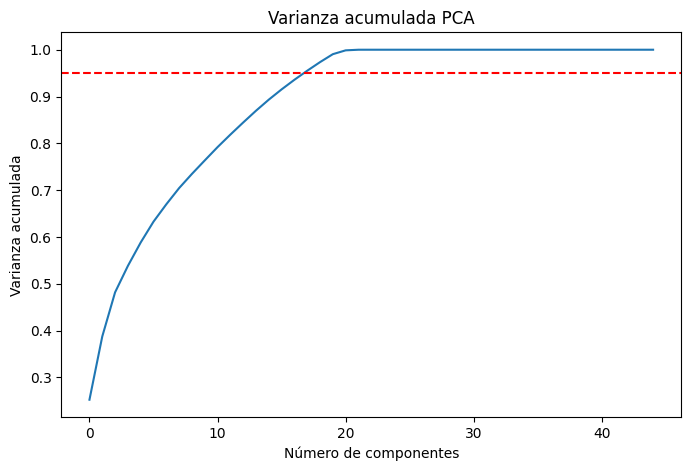

In [29]:
X_encoded = pd.get_dummies(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(explained_variance)

plt.axhline(
    y=0.95,
    color='r',
    linestyle='--'
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")

plt.title("Varianza acumulada PCA")

plt.show()

### Figura 5. Varianza acumulada explicativa por PCA
La Figura 5 muestra la varianza acumulada explicada por los componentes principales obtenidos mediante PCA. Se observa que la varianza aumenta progresivamente a medida que se incorporan más componentes.

Además, la línea de referencia del 95% de varianza acumulada es alcanzada aproximadamente con 17 componentes principales, lo que indica que es posible reducir la dimensionalidad del dataset conservando la mayor parte de la información original.

Esto evidencia que PCA permite disminuir la complejidad del problema sin generar una pérdida significativa de información relevante para la predicción de churn.

### Selección de componentes
Se seleccionó el número de componentes principales que permiten conservar aproximadamente el 95% de la varianza acumulada del dataset original.

In [30]:
n_components = np.argmax(
    explained_variance >= 0.95
) + 1

pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print("Número de componentes:", n_components)

Número de componentes: 18


El anterior procedimiento, permite identificar automáticamente el primer componente donde la varianza acumulada alcanza o supera el 95%. Como resultado, se seleccionaron 18 componentes principales.

Posteriormente, se aplicó nuevamente PCA utilizando únicamente estos 18 componentes. Esto permitió transformar el conjunto de datos original en una representación de menor dimensionalidad, conservando la mayor parte de la información relevante para la predicción de churn y reduciendo la complejidad del problema.

### 5.3. Extracción de características no lineal (UMAP)

In [31]:
!pip install umap-learn

In [32]:
import umap.umap_ as umap

In [33]:
umap_model = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

print(X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(7032, 5)


Como resultado, el dataset original fue transformado a una representación de 5 componentes, obteniendo una nueva matriz de tamaño (7032, 5).

Esto permitió reducir significativamente la dimensionalidad del problema respecto al conjunto original de variables, conservando información relevante para las etapas posteriores de clasificación y evaluación de modelos.

### Reentrenamiento de los mejores modelos

In [34]:
top_models = results_df.sort_values(
    by='F1-score',
    ascending=False
).head(2)

top_models

,Model,Best Params,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,{'model__C': 1},0.725657,0.490132,0.796791,0.606925,0.835093
3,SVM,"{'model__C': 1, 'model__kernel': 'rbf'}",0.729211,0.494017,0.772727,0.602711,0.805617


A partir de los resultados obtenidos durante la etapa de entrenamiento y evaluación, se seleccionaron los modelos Logistic Regression y SVM como los dos mejores modelos del proyecto, tomando como criterio principal el valor de F1-score.

El modelo Logistic Regression obtuvo el mejor desempeño general, alcanzando un F1-score de 0.6069 y un ROC-AUC de 0.8351, mostrando una buena capacidad para identificar clientes con riesgo de abandono.

Por su parte, el modelo SVM presentó un desempeño similar, con un F1-score de 0.6027 y un Recall de 0.7727, evidenciando también una adecuada capacidad discriminativa.

Debido a sus resultados equilibrados en términos de Recall, F1-score y ROC-AUC, ambos modelos fueron seleccionados para las etapas posteriores de reducción de dimensión mediante PCA y UMAP.

## Discusión y conclusiones
En este proyecto se evaluaron diferentes modelos de clasificación supervisada para predecir el abandono de clientes en una empresa de telecomunicaciones utilizando el dataset Telco Customer Churn. Los resultados obtenidos permitieron identificar diferencias importantes en el desempeño de los modelos evaluados y en la capacidad discriminativa de las variables utilizadas.

Durante la etapa de entrenamiento y evaluación, los modelos Logistic Regression y SVM presentaron los resultados más equilibrados considerando métricas como Recall, F1-score y ROC-AUC. En particular, Logistic Regression obtuvo el mejor desempeño general, alcanzando un Recall de 0.7968 y un ROC-AUC de 0.8351, mostrando una buena capacidad para identificar clientes con riesgo de abandono.

El análisis de las curvas ROC evidenció que todos los modelos lograron una capacidad discriminativa adecuada, ya que sus curvas se mantuvieron por encima de la línea de clasificación aleatoria. Sin embargo, Logistic Regression y Random Forest presentaron los mejores valores de AUC, confirmando un mejor balance entre sensibilidad y especificidad.

Por otra parte, la matriz de confusión permitió observar que el mejor modelo logró identificar correctamente una gran cantidad de clientes churn, aunque todavía se presentan falsos positivos y falsos negativos. Esto es esperable debido al desbalance de clases presente en el problema.

El análisis individual de variables mostró que características relacionadas con el tipo de contrato, el tiempo de permanencia (tenure) y algunos servicios adicionales poseen una alta capacidad discriminativa respecto a la variable objetivo. Además, la matriz de correlación evidenció una relación fuerte entre tenure y TotalCharges, indicando cierta redundancia entre variables numéricas.

Respecto a la reducción de dimensión, PCA permitió reducir la complejidad del dataset conservando aproximadamente el 95% de la varianza original mediante 18 componentes principales. Esto demuestra que es posible representar gran parte de la información del problema utilizando un número menor de variables.

Asimismo, la aplicación de UMAP permitió generar una representación no lineal de únicamente 5 componentes, reduciendo considerablemente la dimensionalidad del dataset y preservando relaciones complejas entre las variables.

En general, los resultados obtenidos muestran que los modelos lineales y no lineales presentan un desempeño competitivo para el problema de predicción de churn en telecomunicaciones. Además, las técnicas de reducción de dimensión permitieron disminuir la complejidad del problema manteniendo información relevante para la clasificación, lo cual puede contribuir a mejorar la eficiencia computacional y la capacidad de generalización de los modelos.